In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [ ]:
import re
import glob
from collections import namedtuple


In [3]:
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/ASpirit",)
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [ ]:
pypaths = ('/Users/hernando/work/investigacion/NEXT/software/nextana',
           '/Users/hernando/work/investigacion/NEXT/software/hipy', 
           '/Users/hernando/work/investigacion/NEXT/software/IC', 
           '/Users/hernando/miniconda/envs/IC-3.8-2024-06-08/lib/python38.zip', 
           '/Users/hernando/miniconda/envs/IC-3.8-2024-06-08/lib/python3.8', 
           '/Users/hernando/miniconda/envs/IC-3.8-2024-06-08/lib/python3.8/lib-dynload',
            '/Users/hernando/miniconda/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [4]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [7]:
from sklearn.cluster import DBSCAN
#from sklearn.cluster import DBSCAN

In [8]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

#import nana.kr.krana    as krana
#import nana.kr.kr100ana as krn100
#import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
pltext.style()

In [9]:
pathdata = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits/"

from os import listdir

filenames = listdir(pathdata)
filenames.sort()
#print('fist files: ', filenames[0], filenames[-1])
filenames = [pathdata + '/' + ifile for ifile in filenames if ifile.find('.h5') > 0]
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])


number of files : 7
fist files:  /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_1_0000.h5 /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_7_0000.h5


In [10]:
#kdst = load_dsts(filenames, "DST", "Events")
hits  = load_dsts(filenames, "RECO", "Events")

In [11]:
hits

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,1002,1.752754e+09,29,-13.72357,-22.474468,1,-312.575,29.725,0.0,0.0,819.497000,5.284064,0.253553,-1.0,1.343636e-06,-1,-1.0
1,1002,1.752754e+09,29,-13.72357,-22.474468,1,-189.175,-464.375,0.0,0.0,819.497000,5.915947,0.283873,-1.0,NaN,-1,-1.0
2,1002,1.752754e+09,29,-13.72357,-22.474468,1,-19.125,245.925,0.0,0.0,819.497000,5.733700,0.275128,-1.0,1.467139e-06,-1,-1.0
3,1002,1.752754e+09,29,-13.72357,-22.474468,1,458.925,-124.775,0.0,0.0,819.497000,6.535708,0.313612,-1.0,2.386047e-06,-1,-1.0
4,1002,1.752754e+09,29,-13.72357,-22.474468,1,412.275,-1.375,0.0,0.0,819.497000,6.571945,0.315351,-1.0,1.803902e-06,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63340967,3825003,1.752840e+09,28,-50.09021,70.791589,1,-112.425,-109.725,0.0,0.0,272.440375,5.038843,-0.186281,-1.0,-9.611699e-07,-1,-1.0
63340968,3825003,1.752840e+09,28,-50.09021,70.791589,1,-19.125,75.875,0.0,0.0,272.440375,5.707632,-0.211006,-1.0,-1.063815e-06,-1,-1.0
63340969,3825003,1.752840e+09,28,-50.09021,70.791589,1,42.075,-479.925,0.0,0.0,272.440375,6.375054,-0.235680,-1.0,-2.185854e-06,-1,-1.0
63340970,3825003,1.752840e+09,28,-50.09021,70.791589,1,73.175,-31.975,0.0,0.0,272.440375,5.156217,-0.190620,-1.0,-9.458313e-07,-1,-1.0


In [13]:
esum = hits.groupby("event").sum()

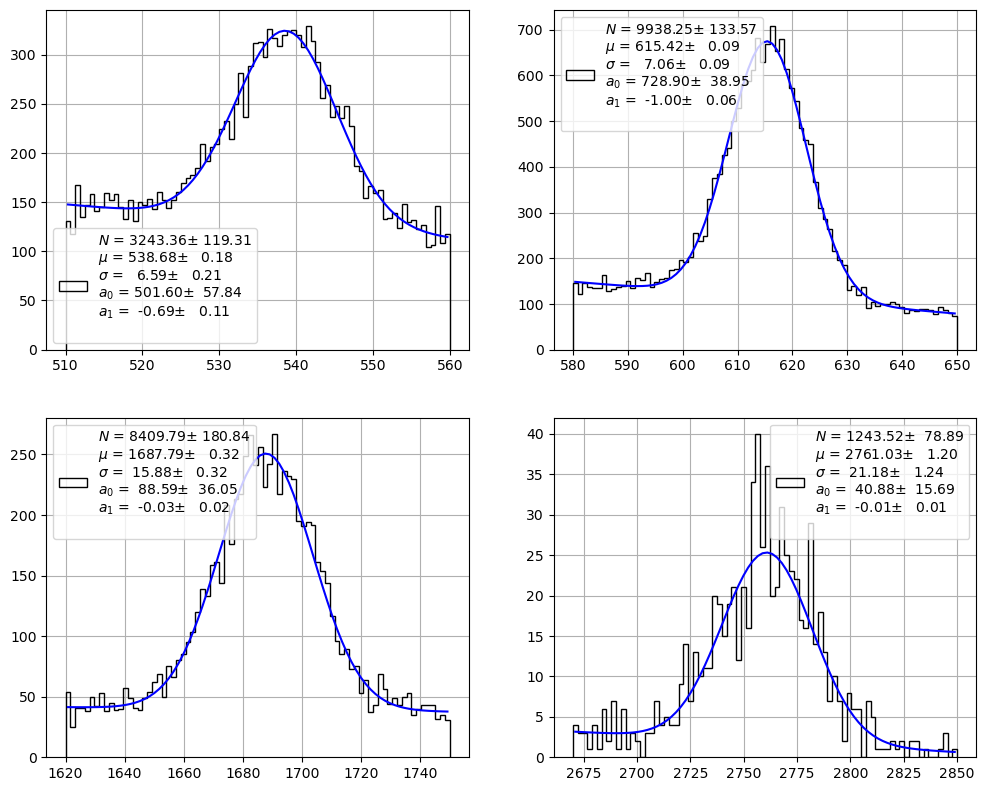

In [14]:
pranges  = [(510, 560), (580, 650), (1620, 1750), (2670, 2850)]
energy = esum.Ec
cv = pltext.canvas(6, 2)
p0 = np.array((1e2, 0.53, 0.05))
#for i, irange in enumerate(peak_ranges_d):
i = 5
for i, irange in enumerate(pranges):
    cv(i+1); pltext.hfit(1e3*energy, fun = 'gaus+Polynomial.1', bins = 80, range = irange);


In [15]:
hits

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,1002,1.752754e+09,29,-13.72357,-22.474468,1,-312.575,29.725,0.0,0.0,819.497000,5.284064,0.253553,-1.0,1.343636e-06,-1,-1.0
1,1002,1.752754e+09,29,-13.72357,-22.474468,1,-189.175,-464.375,0.0,0.0,819.497000,5.915947,0.283873,-1.0,NaN,-1,-1.0
2,1002,1.752754e+09,29,-13.72357,-22.474468,1,-19.125,245.925,0.0,0.0,819.497000,5.733700,0.275128,-1.0,1.467139e-06,-1,-1.0
3,1002,1.752754e+09,29,-13.72357,-22.474468,1,458.925,-124.775,0.0,0.0,819.497000,6.535708,0.313612,-1.0,2.386047e-06,-1,-1.0
4,1002,1.752754e+09,29,-13.72357,-22.474468,1,412.275,-1.375,0.0,0.0,819.497000,6.571945,0.315351,-1.0,1.803902e-06,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63340967,3825003,1.752840e+09,28,-50.09021,70.791589,1,-112.425,-109.725,0.0,0.0,272.440375,5.038843,-0.186281,-1.0,-9.611699e-07,-1,-1.0
63340968,3825003,1.752840e+09,28,-50.09021,70.791589,1,-19.125,75.875,0.0,0.0,272.440375,5.707632,-0.211006,-1.0,-1.063815e-06,-1,-1.0
63340969,3825003,1.752840e+09,28,-50.09021,70.791589,1,42.075,-479.925,0.0,0.0,272.440375,6.375054,-0.235680,-1.0,-2.185854e-06,-1,-1.0
63340970,3825003,1.752840e+09,28,-50.09021,70.791589,1,73.175,-31.975,0.0,0.0,272.440375,5.156217,-0.190620,-1.0,-9.458313e-07,-1,-1.0


In [28]:
def label_hits(df, scale = (14.55, 15.55, 3.7), eps = 2.3, max_clusters = 5):
    coors = df[['X', 'Y', 'Z']].to_numpy()
        
    coors[:, :2] /= scale[0]
    coors[:, 2]  /= scale[2]
        
    labels = DBSCAN(eps = eps, min_samples = max_clusters).fit_predict(coors)
    return labels


In [42]:
df = hits.groupby(['event'])
df.get_group(1002)

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,1002,1.752754e+09,29,-13.72357,-22.474468,1,-312.575,29.725,0.0,0.0,819.497000,5.284064,0.253553,-1.0,1.343636e-06,-1,-1.0
1,1002,1.752754e+09,29,-13.72357,-22.474468,1,-189.175,-464.375,0.0,0.0,819.497000,5.915947,0.283873,-1.0,NaN,-1,-1.0
2,1002,1.752754e+09,29,-13.72357,-22.474468,1,-19.125,245.925,0.0,0.0,819.497000,5.733700,0.275128,-1.0,1.467139e-06,-1,-1.0
3,1002,1.752754e+09,29,-13.72357,-22.474468,1,458.925,-124.775,0.0,0.0,819.497000,6.535708,0.313612,-1.0,2.386047e-06,-1,-1.0
4,1002,1.752754e+09,29,-13.72357,-22.474468,1,412.275,-1.375,0.0,0.0,819.497000,6.571945,0.315351,-1.0,1.803902e-06,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,1002,1.752754e+09,29,-13.72357,-22.474468,1,26.525,-94.175,0.0,0.0,1078.210125,6.014832,-0.189021,-1.0,-9.914047e-07,-1,-1.0
704,1002,1.752754e+09,29,-13.72357,-22.474468,1,134.375,-0.875,0.0,0.0,1078.210125,5.937361,-0.186586,-1.0,-9.951590e-07,-1,-1.0
705,1002,1.752754e+09,29,-13.72357,-22.474468,1,-173.625,-170.925,0.0,0.0,1082.931500,5.041929,0.680244,-1.0,3.579359e-06,-1,-1.0
706,1002,1.752754e+09,29,-13.72357,-22.474468,1,-112.425,230.375,0.0,0.0,1082.931500,5.696793,0.768596,-1.0,4.150973e-06,-1,-1.0


In [44]:
events = np.unique(hits['event'].values)
events

array([     12,      86,     122, ..., 3825123, 3825173, 3825205])

In [62]:
ievt = events[7]
print(ievt)
idf = hits[hits.event == ievt]
labels = label_hits(idf)

793


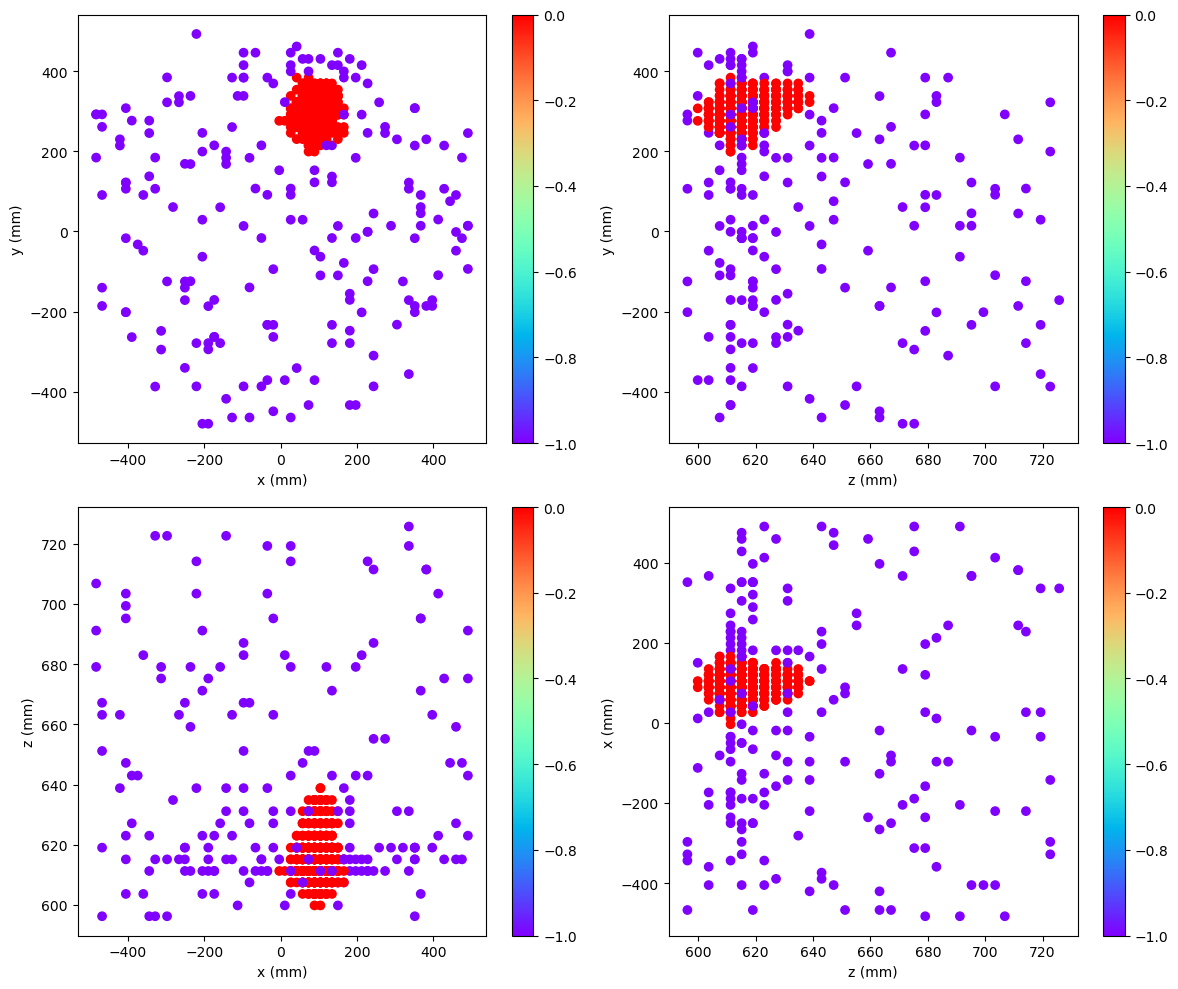

In [63]:
cv = pltext.canvas(4, 2)
cv(1); plt.scatter(idf.X, idf.Y, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('x (mm)'); plt.ylabel('y (mm)')
cv(2); plt.scatter(idf.Z, idf.Y, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('z (mm)'); plt.ylabel('y (mm)')
cv(3); plt.scatter(idf.X, idf.Z, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('x (mm)'); plt.ylabel('z (mm)')
cv(4); plt.scatter(idf.Z, idf.X, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('z (mm)'); plt.ylabel('x (mm)')
plt.tight_layout()


In [ ]:
def label_hit(hits, scales = (14.55, 14.55, 3.7), eps = 2.3, max_clusters = 5):
    a = 14.55  # XY scale
    b = 3.7  # Z scale

    # Pre-allocate array for cluster labels
    cluster_labels = np.full(len(hits), -9999, dtype=int)

    # Get values once (faster than repeatedly accessing DataFrame columns)
    coords = hits[['X', 'Y', 'Z']].to_numpy()
    events = hits['event'].to_numpy()
    
    # Use np.unique to get sorted event IDs
    unique_events = np.unique(events)
    
    for idf in hits.groupby(["event"]):
        coors = idf[['X', 'Y', 'Z']].to_numpy()
        
        # Scale
        coors[:, :2] /= a
        coors[:, 2]  /= b
        
        labels = DBSCAN(eps = eps, min_samples = max_clusters).fit_predict(X)
    return labels

SyntaxError: invalid syntax (3713795323.py, line 20)

In [15]:
esum = hits.groupby("event").sum()

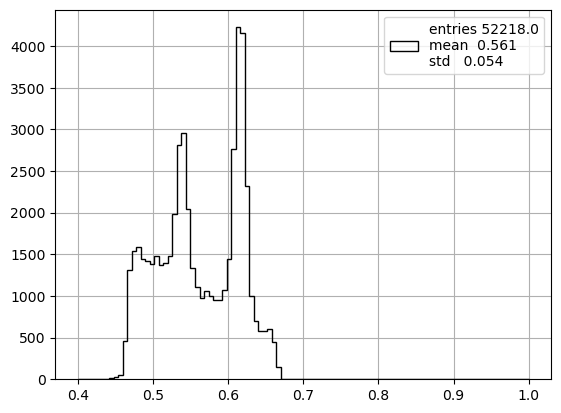

In [73]:
pltext.hist(esum.Ec, 100, (0.4, 1.));

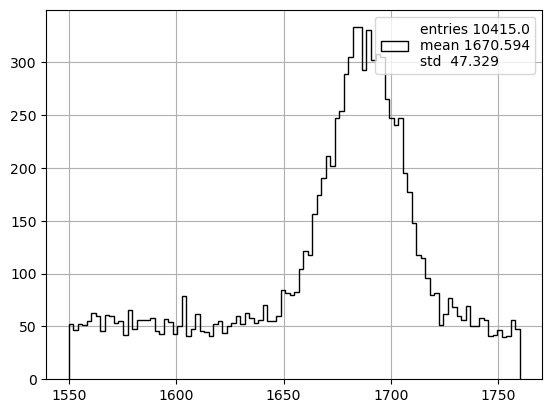

In [39]:
pltext.hist(1000.*esum.Ec, 100, range = (1550, 1760));

In [56]:
pol = getattr(np.polynomial, "Polynomial")

In [65]:
pol([1, 2])(np.array((1, 2, 3, 4)))

array([3., 5., 7., 9.])

In [46]:
f(np.arange(10))

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])

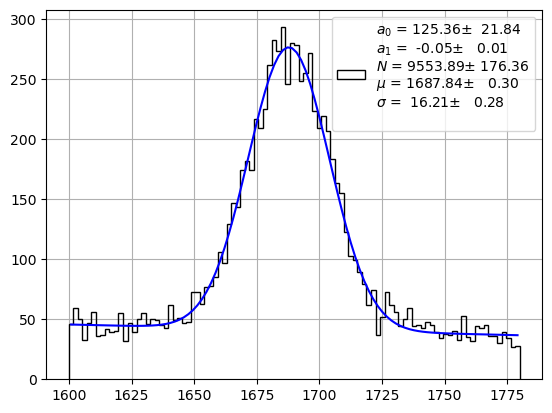

In [67]:
pltext.hfit(1000.*esum.Ec, 100, fun = 'Polynomial.1+gaus', range = (1600, 1780));

In [27]:
dst_summ, reco_summ, eff_summ = pd.DataFrame([]), pd.DataFrame([]), pd.DataFrame([])
for run_n in run_numbers:
    filename = pathdata + f"run_cut_{run_n}.h5"
    #path= path.format(run_folder = run_folder, run_number = run_n) + run_summary_name.format(run_n)
    run_dst  = pd.read_hdf(filename, 'DST/Events')
    run_dst['run_n'] = str(run_n)
    run_reco = pd.read_hdf(filename, 'RECO/Events_summary')
    eff = pd.read_hdf(filename, 'RUN/eff')
    eff['run_n'] = run_n

    dst_summ = dst_summ.append(run_dst)
    reco_summ = reco_summ.append(run_reco)
    eff_summ = eff_summ.append(eff)

In [37]:
reco_summ = reco_summ.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})
reco_summ['total_energy_d'] = reco_summ['total_energy'] - reco_summ['Ec_drop_out'] # - reco_summ['Ec_drop_in']

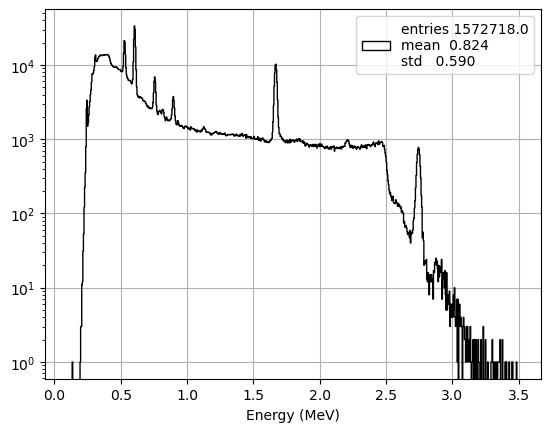

In [49]:
pltext.hist(reco_summ.total_energy_d, 800, (.1, 3.5));
plt.xlabel('Energy (MeV)'); plt.yscale('log');

In [ ]:
def get_peak(energy, bins = 100, range = (0, 3e3))
    _, _, _, pars, epars, _ = histos.hfit(energy, bins, fun = "gaus+exp", range = range)
    


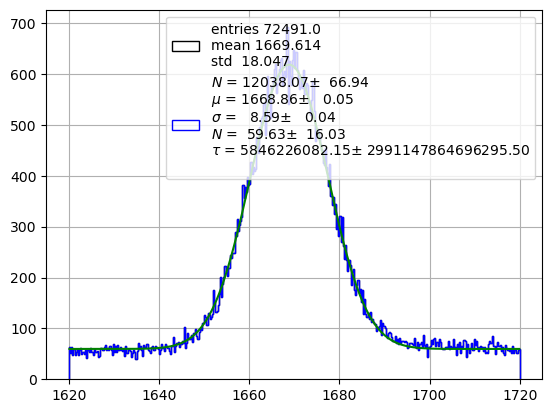

In [64]:
scale = 1e3
pltext.hist(scale*reco_summ.total_energy_d, 400, (scale*1.62, scale*1.72));
pltext.hfit(scale*reco_summ.total_energy_d, 400, fun = 'gaus+exp', range = (scale*1.62, scale*1.72));

In [209]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,Y_bary,Z_bary,total_E,total_energy,num_hits,Ec_drop_in,nhits_drop_in,Ec_drop_out,nhits_drop_out,total_energy_d
11,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,-140.575041,663.460993,339022.818697,1.852308,1261,0.041174,83,0.008404,21,1.843904
43,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,43.714905,912.947330,63996.899463,0.351425,229,0.012001,13,0.004922,16,0.346503
65,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,-219.095438,819.622523,331282.290316,1.794716,1286,0.040074,74,0.006229,10,1.788487
23,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,-61.531167,919.496907,69378.268448,0.386220,253,0.006537,12,0.014065,16,0.372155
53,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,-37.438234,398.525620,143315.489953,0.755627,486,0.014002,31,0.008478,14,0.747150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,159.308605,693.238208,110677.212640,0.598111,456,0.020475,38,0.001844,12,0.596266
13,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,-6.786320,577.540461,64412.395411,0.366932,223,0.008872,22,0.006377,9,0.360555
47,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,103.155084,935.400033,114267.442543,0.617315,479,0.018765,29,0.003201,4,0.614114
54,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,-75.092490,851.997868,64883.624815,0.359839,249,0.019170,22,0.004064,20,0.355775


In [219]:
run_n = run_numbers[0]
energy = reco_summ[reco_summ.run_n == str(run_n) ].total_energy_d
print(len(energy))
#pltext.hist(1e3*energy, 500, (0, 3.8e6));

206103


In [220]:
run_n = run_numbers[0]
energy = reco_summ[reco_summ.run_n == str(run_n)].total_energy_d.values
bins   = 400
range = (1620, 1720)
def get_peak(energy, range, bins = 100):
    _, _, _, pars, epars, _ = histos.hfit(energy, bins, fun = "gaus+exp", range = range)
    mu, sigma = pars[1], pars[2]
    emu, esigma = epars[1], epars[2]
    return mu, emu, sigma, esigma

In [221]:
peak_ranges   = [(0.5, 0.58), (0.58, 0.65), (0.72, 0.81), (0.85, 0.95), (1.62, 1.75), (2.7, 2.8)]
peak_ranges_d = [(0.48, 0.56), (0.57, 0.64), (0.71, 0.80), (0.85, 0.95), (1.59, 1.72), (2.68, 2.79)]

/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


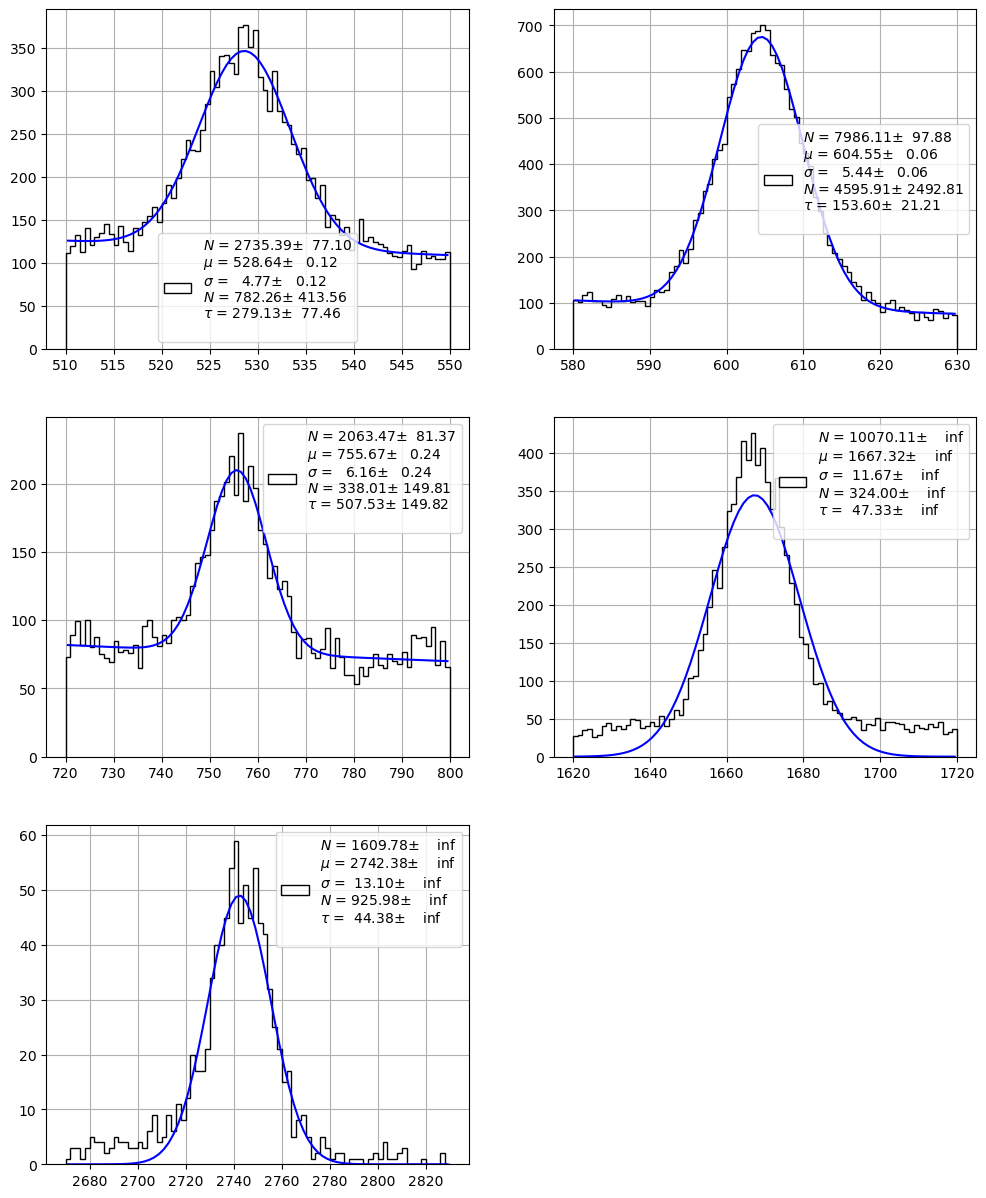

In [223]:
pranges  = [(0.51, 0.55), (0.58, 0.63), (0.72, 0.80), (1.62, 1.72), (2.67, 2.83)]
cv = pltext.canvas(6, 2)
p0 = np.array((1e2, 0.53, 0.05))
#for i, irange in enumerate(peak_ranges_d):
i = 5
for i, irange in enumerate(pranges):
    cv(i+1); pltext.hfit(1e3*energy, fun = 'gaus+exp', bins = 80, range = 1e3*np.array(irange));
#vals = [get_peak(energy, range) for range in peak_ranges_d]

In [196]:
pranges  = [(0.51, 0.55), (0.58, 0.63), (0.72, 0.80), (1.62, 1.72), (2.67, 2.83)]
vals = [get_peak(1e3*energy, range = 1e3*np.array(irange), bins = 400) for irange in pranges]#vals = [get_peak(energy, range) for range in peak_ranges_d]

In [197]:
vals

[(529.1221765269046,
  0.04312056612790292,
  4.999026251331807,
  0.04663885827662838),
 (605.1350336390645,
  0.023814021632212645,
  5.4754554218904,
  0.023210208268350734),
 (756.5705992685588,
  0.08337091634140209,
  6.162107646604556,
  0.08365794396834988),
 (1668.8612462301135,
  0.04876067731261533,
  8.593481308799348,
  0.04452136548869566),
 (2745.03749804094,
  0.19411825846338812,
  12.365539322467907,
  0.17479739947992182)]

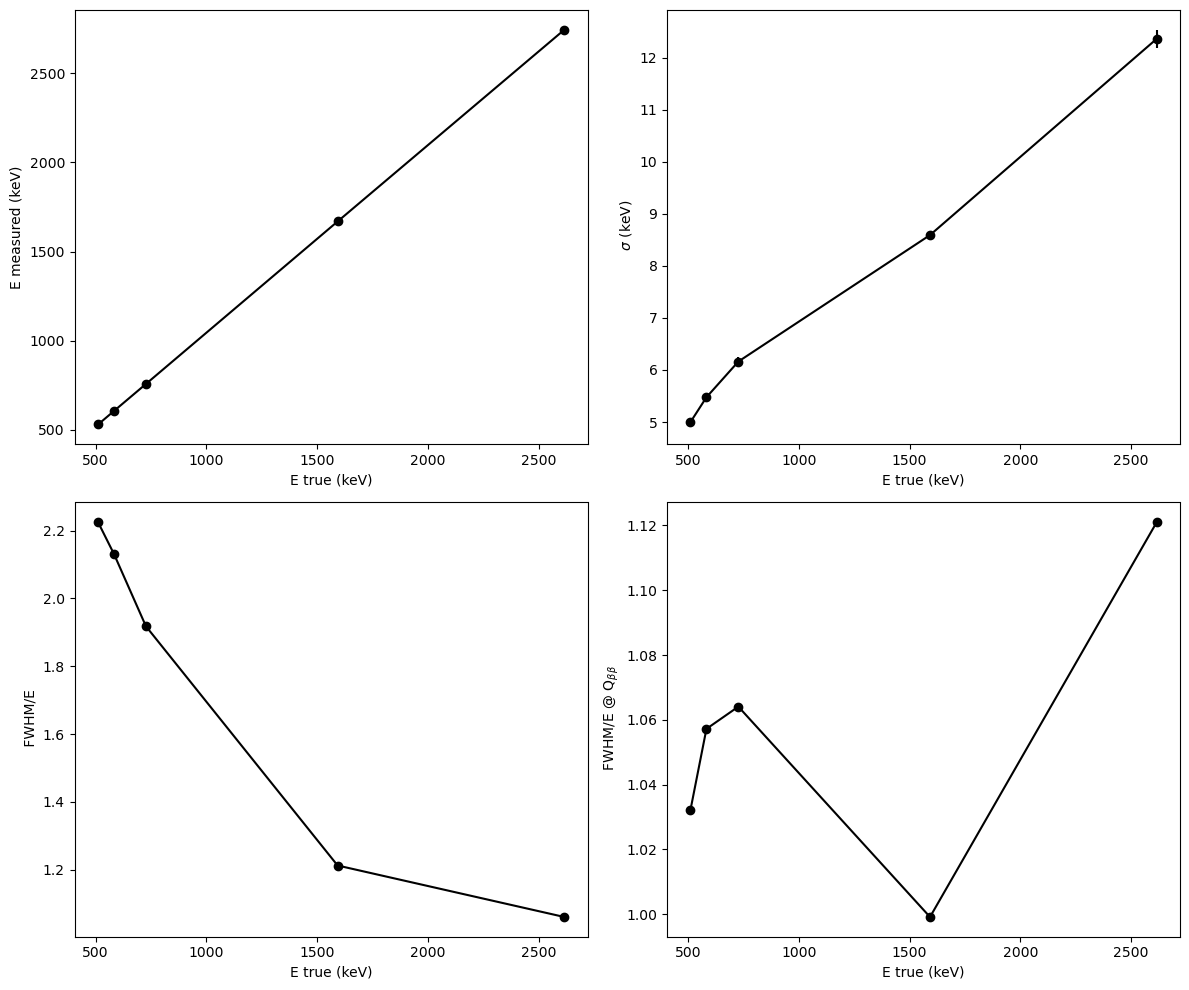

In [207]:
peak_true  = 1e3*np.array([0.511, 0.583, 0.727, 1.592, 2.615])
peak_meas  = np.array([v[0] for v in vals])
peak_emeas = np.array([v[1] for v in vals])
peak_sig   = np.array([v[2] for v in vals])
peak_esig  = np.array([v[3] for v in vals])
Qbb = 2458.
cv = pltext.canvas(3, 2)
cv(1); plt.errorbar(peak_true, peak_meas, yerr = peak_emeas, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel("E measured (keV)")
cv(2); plt.errorbar(peak_true, peak_sig, yerr = peak_esig, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" $\sigma$ (keV)")
cv(3); plt.plot(peak_true, 235.48 * peak_sig/peak_meas, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" FWHM/E")
cv(4); plt.plot(peak_true, 235.48 * peak_sig /peak_meas * np.sqrt(peak_meas/Qbb), marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" FWHM/E @ Q$_{\beta\beta}$")
plt.tight_layout();


In [ ]:
pltext.hist(reco_summ.total_energy_d, 500, (0, 3));

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,X_bary,Y_bary,Z_bary,total_E,total_energy,num_hits,Ec_drop_in,nhits_drop_in,Ec_drop_out,nhits_drop_out
11,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,268.259795,-140.575041,663.460993,339022.818697,1.852308,1261,0.041174,83,0.008404,21
43,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,139.036401,43.714905,912.947330,63996.899463,0.351425,229,0.012001,13,0.004922,16
65,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,211.142176,-219.095438,819.622523,331282.290316,1.794716,1286,0.040074,74,0.006229,10
23,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,-267.817024,-61.531167,919.496907,69378.268448,0.386220,253,0.006537,12,0.014065,16
53,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,-168.523569,-37.438234,398.525620,143315.489953,0.755627,486,0.014002,31,0.008478,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,-15.589238,159.308605,693.238208,110677.212640,0.598111,456,0.020475,38,0.001844,12
13,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,355.499240,-6.786320,577.540461,64412.395411,0.366932,223,0.008872,22,0.006377,9
47,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,1.523561,103.155084,935.400033,114267.442543,0.617315,479,0.018765,29,0.003201,4
54,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,163.573332,-75.092490,851.997868,64883.624815,0.359839,249,0.019170,22,0.004064,20
